In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import CommunityModelClass3 as cmc3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from scipy.optimize import curve_fit

save_directory = "phase_richness"
isExist = os.path.exists(save_directory)
if not isExist:
    os.makedirs(save_directory)

In [3]:
# functions cell

def Phase_search(N_sim,wk_fine,leakage,output_name):
    inputs["leakage"] = leakage
    results = np.zeros((N_sim,len(wk_fine)))

    for epoch in range(N_sim):
        for i in range(len(wk_fine)):

            print("epoch:", epoch, end="\r")
            inputs["k_0"]=wk_fine[i]

            model=cmc3.CommunityModel(inputs)
            model.Simulate()

            data=model.ReturnData("species")[-1] 

            data[data<1e-3]=0
            dd=len(np.nonzero(data)[0])

            results[epoch][i]=dd    

    mean_results=np.mean(results,axis=0) 
    std_results=np.std(results,axis=0)

    output=np.array([mean_results,std_results])
    store_output=pd.DataFrame(output.T)
    store_output.to_csv(save_directory+"/"+output_name,index=False,header=False)

#----------------------------------------------------------------------------------------------

def sigmoid(x, L ,x0, k, b):
    y = L / (1 + np.exp(-k*(x-x0))) + b
    return y

#----------------------------------------------------------------------------------------------

def Sigmoid_fit(wk_fine,mean_results,output_name):
    from scipy.optimize import curve_fit

    p0 = [max(mean_results), np.median(wk_fine), 1, min(mean_results)] 
    popt, pcov = curve_fit(sigmoid, wk_fine, mean_results, p0, maxfev=int(1e5),method="trf")

    params = pd.DataFrame(popt)
    variance = pd.DataFrame(pcov)

    save_directory = "phase_richness"
    params.to_csv(save_directory+"/fit_params_"+output_name,header=False,index=False)
    variance.to_csv(save_directory+"/fit_var_"+output_name,header=False,index=False)

    fit=sigmoid(wk_fine,*popt)
    residuals= mean_results - fit

    return np.array([fit,residuals])

#----------------------------------------------------------------------------------------------

def Fit_plots(wk_fine,mean_results,fit,residuals,std_results,leakage):
    fig, ax = plt.subplots(1,2,figsize=(12,4))
    fig.suptitle("Leakage={}".format(leakage))

    ax[0].set(title="Sigmoid Fit")
    ax[0].scatter(wk_fine,mean_results,marker=".",label="Simulated Data")
    ax[0].plot(wk_fine,fit,ls="dashed",color="firebrick",label="Sigmoid Fit")
    ax[0].set_xscale("log")
    ax[0].set_xlabel("$w_0k_0$")
    ax[0].set_ylabel("Mean Richness")
    ax[0].grid(alpha=0.5)
    ax[0].legend();

    ax[1].set(title="Residuals")
    ax[1].errorbar(wk_fine,residuals,yerr=std_results,fmt=".")
    ax[1].plot(wk_fine,np.zeros_like(wk_fine),ls="--",c="firebrick")
    ax[1].set_xscale("log")
    ax[1].set_xlabel("$w_0k_0$")
    ax[1].grid(alpha=0.5)

#----------------------------------------------------------------------------------------------

def CriticalPoint(curve, wk, popt):
    a = np.diff(curve)
    cp_x = wk[1:][a == np.max(a)][0]
    cp_y = sigmoid(cp_x,*popt)   
    return [cp_x,cp_y]


In [4]:
inputs={}

inputs["S_tot"] = 80
inputs["S"] = 40
inputs["R"] = 40

# initial conditions
inputs["S0"] = 10
inputs["R0"] = 5

# time simulation params
inputs["time_period"] = 1e5
inputs["t_step"] = 0.1

# partitions params
inputs["num_F"] = 4
inputs["num_T"] = 4
inputs["partition_F"] = [20]*4
inputs["partition_T"] = [10]*4

# activation function
inputs["sigma_type"] = "linear"
inputs["k"] = 20                           
inputs["N"] = 2

# h function params
inputs["tau_R"] = 1
inputs["k_alpha_index"] = 0

# metabolic matrix params
inputs["f_c"] = 0.25
inputs["f_s"] = 0.25
inputs["d0"] = 0.2

# preference matrix params
inputs["preference_type"] = "binary"
inputs["mu_c"] = 4.5
inputs["sigma_c"] = 0.3
inputs["c_0"] = 1
inputs["c_1"] = 1
inputs["q_A"] = 0.5


# save params:
df_inputs=pd.DataFrame(inputs)
df_inputs.to_csv(save_directory+"/simulation_params_phase_richness.csv")

-----------------

obtaining the data for the fits

In [11]:
N_sim = 10

wk_fine=np.logspace(0, 3, num=30, base=10)
leakage = 0.985

output_name = f"phase_richness_sim10_l{str(leakage)[2:]}.csv"

Phase_search(N_sim,wk_fine,leakage,output_name)

 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5518551302020D+03   r2 =  0.5658762895353D-13
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5518551302020D+03   r2 =  0.5658762895353D-13
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5518551302020D+03   r2 =  0.4432376701845D-13
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5518551302020D+03   r2 =  0.4432376701845D-13
 lsoda--  warning..internal t (=r1) 

In [12]:
results=np.genfromtxt(save_directory+"/"+output_name,delimiter=",")
mean_results=results[:,0]
std_results=results[:,1]

/var/folders/0d/wr4vslms6rx70gkgwp1_dz400000gn/T/ipykernel_79845/1778757111.py:33: RuntimeWarning: overflow encountered in exp
  y = L / (1 + np.exp(-k*(x-x0))) + b


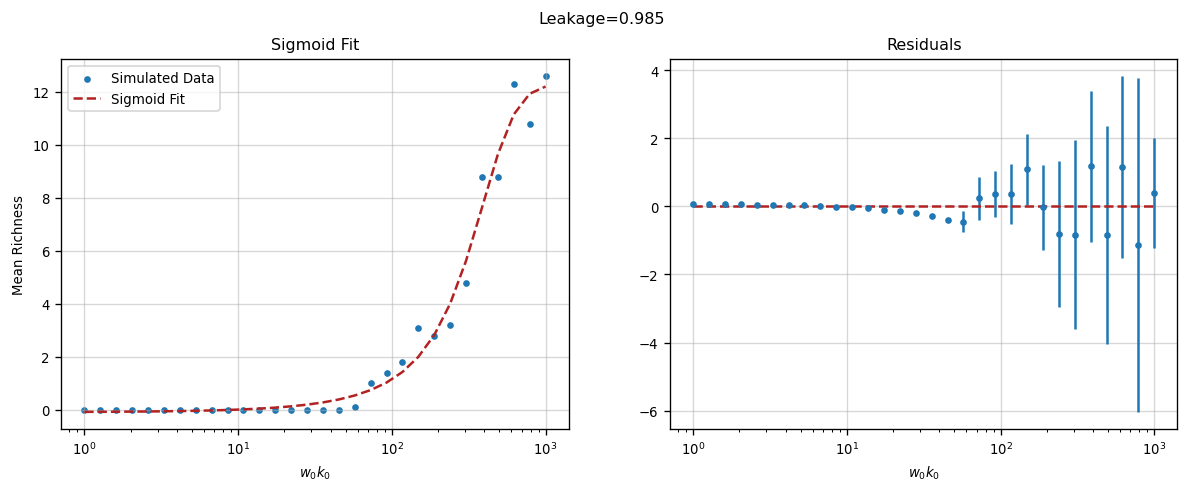

In [13]:
ff=Sigmoid_fit(wk_fine,mean_results,output_name)
fit = ff[0]
residuals = ff[1]

Fit_plots(wk_fine,mean_results,fit,residuals,std_results,leakage)

checking the results:

In [8]:
results_80 = np.genfromtxt(save_directory+"/phase_richness_sim10_l80.csv",delimiter=",")
mean_results_80 = results_80[:,0]
std_results_80 = results_80[:,1]
fit_params_80 = np.genfromtxt(save_directory+"/fit_params_phase_richness_sim10_l80.csv",delimiter=",")
fit_80 = sigmoid(wk_fine, *fit_params_80)
residuals_80 = mean_results_80 -fit_80


results_82 = np.genfromtxt(save_directory+"/phase_richness_sim10_l82.csv",delimiter=",")
mean_results_82 = results_82[:,0]
std_results_82 = results_82[:,1]
fit_params_82 = np.genfromtxt(save_directory+"/fit_params_phase_richness_sim10_l82.csv",delimiter=",")
fit_82 = sigmoid(wk_fine, *fit_params_82)
residuals_82 = mean_results_82 -fit_82


results_84 = np.genfromtxt(save_directory+"/phase_richness_sim10_l84.csv",delimiter=",")
mean_results_84 = results_84[:,0]
std_results_84 = results_84[:,1]
fit_params_84 = np.genfromtxt(save_directory+"/fit_params_phase_richness_sim10_l84.csv",delimiter=",")
fit_84 = sigmoid(wk_fine, *fit_params_84)
residuals_84 = mean_results_84 -fit_84


results_86 = np.genfromtxt(save_directory+"/phase_richness_sim10_l86.csv",delimiter=",")
mean_results_86 = results_86[:,0]
std_results_86 = results_86[:,1]
fit_params_86 = np.genfromtxt(save_directory+"/fit_params_phase_richness_sim10_l86.csv",delimiter=",")
fit_86 = sigmoid(wk_fine, *fit_params_86)
residuals_86 = mean_results_86 -fit_86


results_88 = np.genfromtxt(save_directory+"/phase_richness_sim10_l88.csv",delimiter=",")
mean_results_88 = results_88[:,0]
std_results_88 = results_88[:,1]
fit_params_88 = np.genfromtxt(save_directory+"/fit_params_phase_richness_sim10_l88.csv",delimiter=",")
fit_88 = sigmoid(wk_fine, *fit_params_88)
residuals_88 = mean_results_88 -fit_88


results_90 = np.genfromtxt(save_directory+"/phase_richness_sim10_l9.csv",delimiter=",")
mean_results_90 = results_90[:,0]
std_results_90 = results_90[:,1]
fit_params_90 = np.genfromtxt(save_directory+"/fit_params_phase_richness_sim10_l9.csv",delimiter=",")
fit_90 = sigmoid(wk_fine, *fit_params_90)
residuals_90 = mean_results_90 -fit_90


results_92 = np.genfromtxt(save_directory+"/phase_richness_sim10_l92.csv",delimiter=",")
mean_results_92 = results_92[:,0]
std_results_92 = results_92[:,1]
fit_params_92 = np.genfromtxt(save_directory+"/fit_params_phase_richness_sim10_l92.csv",delimiter=",")
fit_92 = sigmoid(wk_fine, *fit_params_92)
residuals_92 = mean_results_92 -fit_92


results_94 = np.genfromtxt(save_directory+"/phase_richness_sim10_l94.csv",delimiter=",")
mean_results_94 = results_94[:,0]
std_results_94 = results_94[:,1]
fit_params_94 = np.genfromtxt(save_directory+"/fit_params_phase_richness_sim10_l94.csv",delimiter=",")
fit_94 = sigmoid(wk_fine, *fit_params_94)
residuals_94 = mean_results_94 -fit_94


results_96 = np.genfromtxt(save_directory+"/phase_richness_sim10_l96.csv",delimiter=",")
mean_results_96 = results_96[:,0]
std_results_96 = results_96[:,1]
fit_params_96 = np.genfromtxt(save_directory+"/fit_params_phase_richness_sim10_l96.csv",delimiter=",")
fit_96 = sigmoid(wk_fine, *fit_params_96)
residuals_96 = mean_results_96 -fit_96


results_97 = np.genfromtxt(save_directory+"/phase_richness_sim10_l97.csv",delimiter=",")
mean_results_97 = results_97[:,0]
std_results_97 = results_97[:,1]
fit_params_97 = np.genfromtxt(save_directory+"/fit_params_phase_richness_sim10_l97.csv",delimiter=",")
fit_97 = sigmoid(wk_fine, *fit_params_97)
residuals_97 = mean_results_97 -fit_97


results_98 = np.genfromtxt(save_directory+"/phase_richness_sim10_l98.csv",delimiter=",")
mean_results_98 = results_98[:,0]
std_results_98 = results_98[:,1]
fit_params_98 = np.genfromtxt(save_directory+"/fit_params_phase_richness_sim10_l98.csv",delimiter=",")
fit_98 = sigmoid(wk_fine, *fit_params_98)
residuals_98 = mean_results_98 -fit_98


results_99 = np.genfromtxt(save_directory+"/phase_richness_sim10_l99.csv",delimiter=",")
mean_results_99 = results_99[:,0]
std_results_99 = results_99[:,1]
fit_params_99 = np.genfromtxt(save_directory+"/fit_params_phase_richness_sim10_l99.csv",delimiter=",")
fit_99 = sigmoid(wk_fine, *fit_params_99)
residuals_99 = mean_results_99 -fit_99

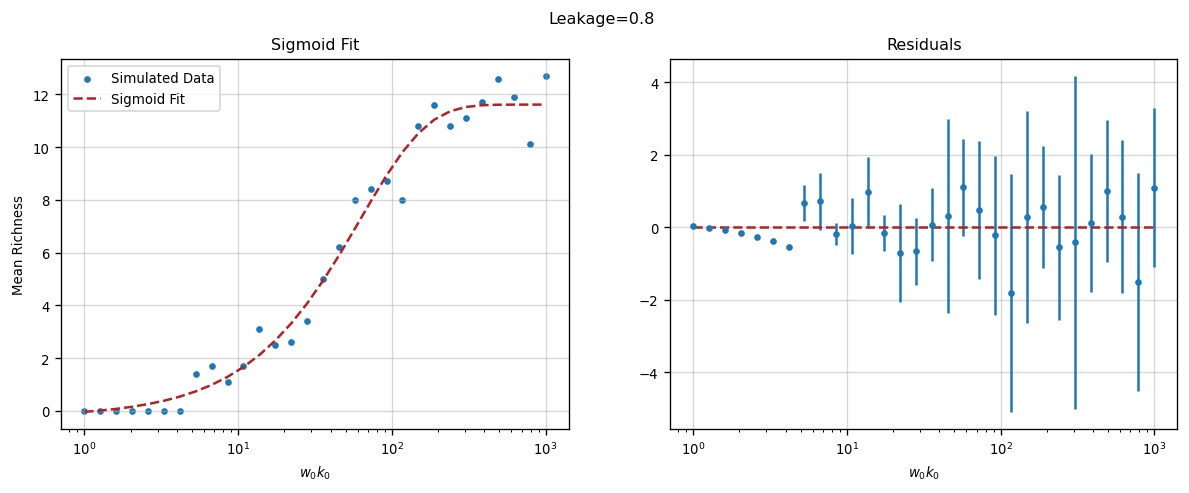

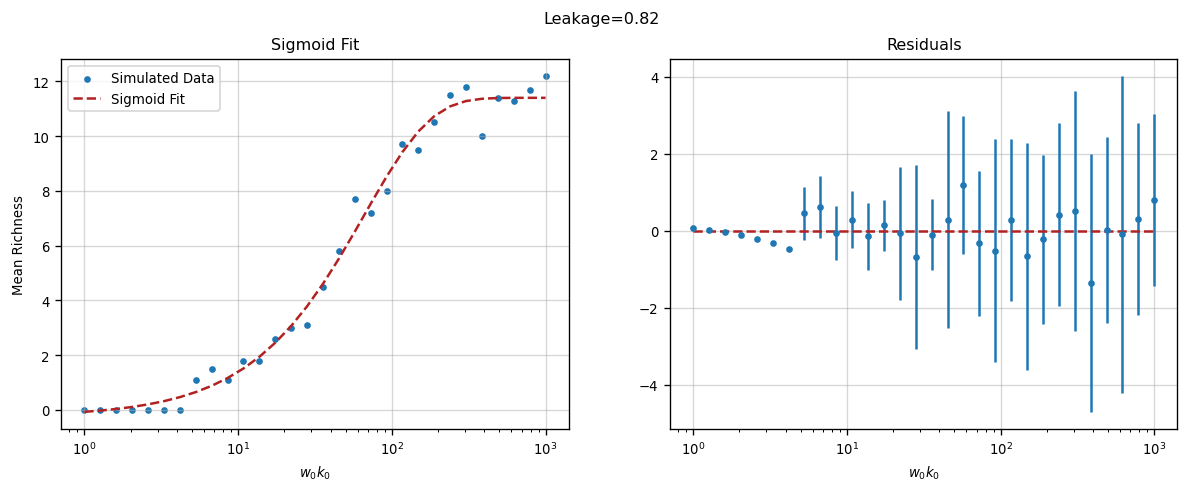

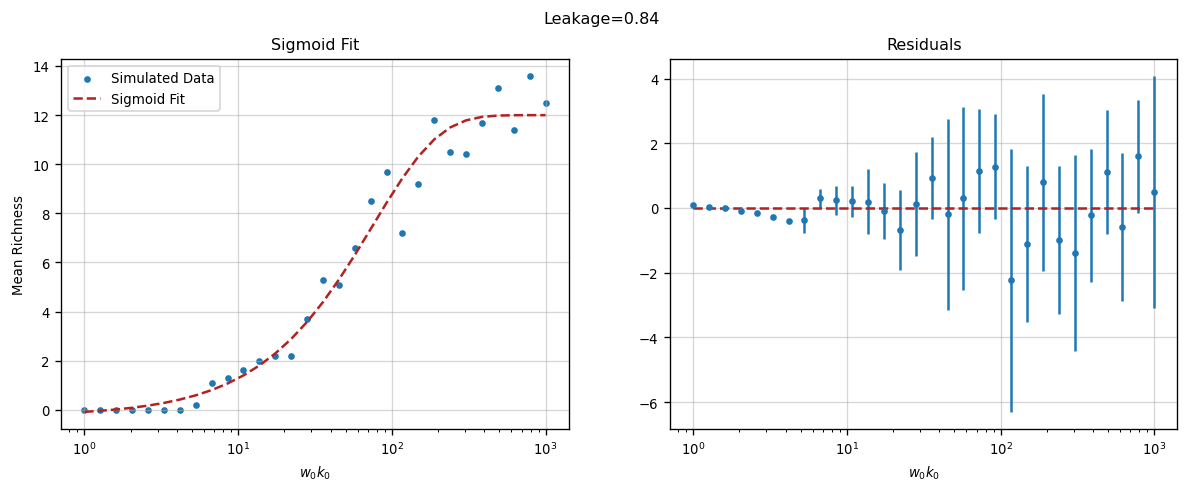

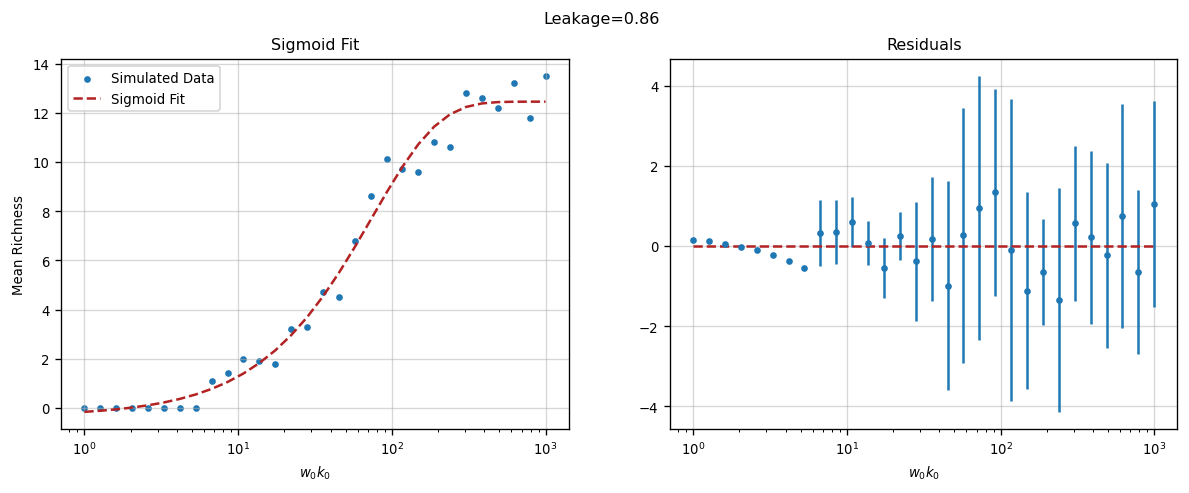

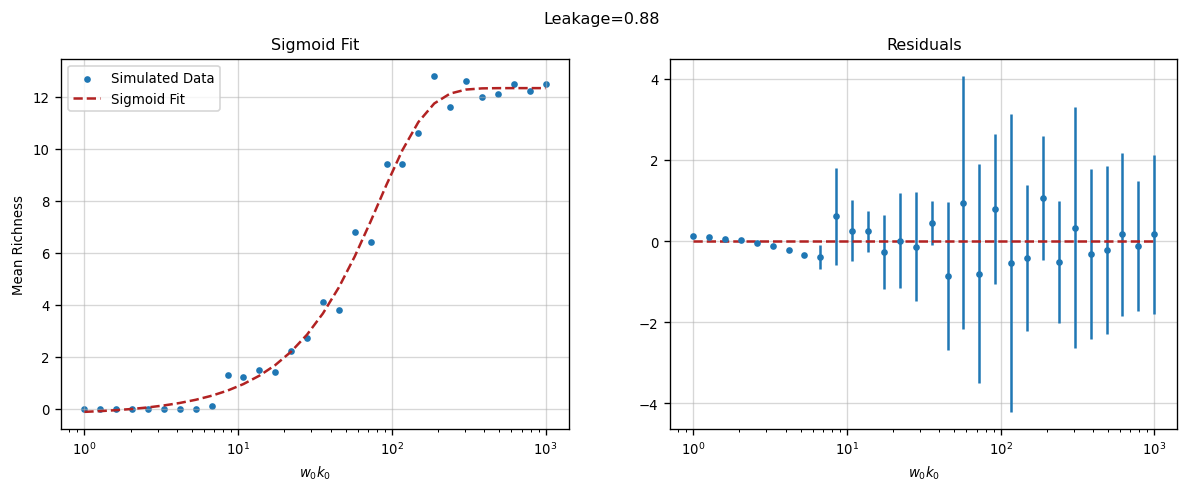

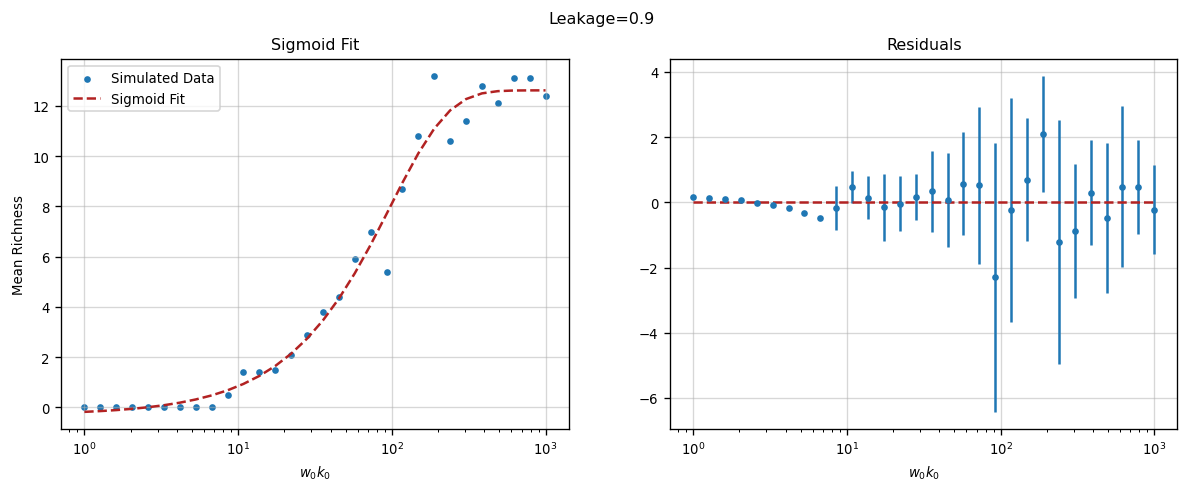

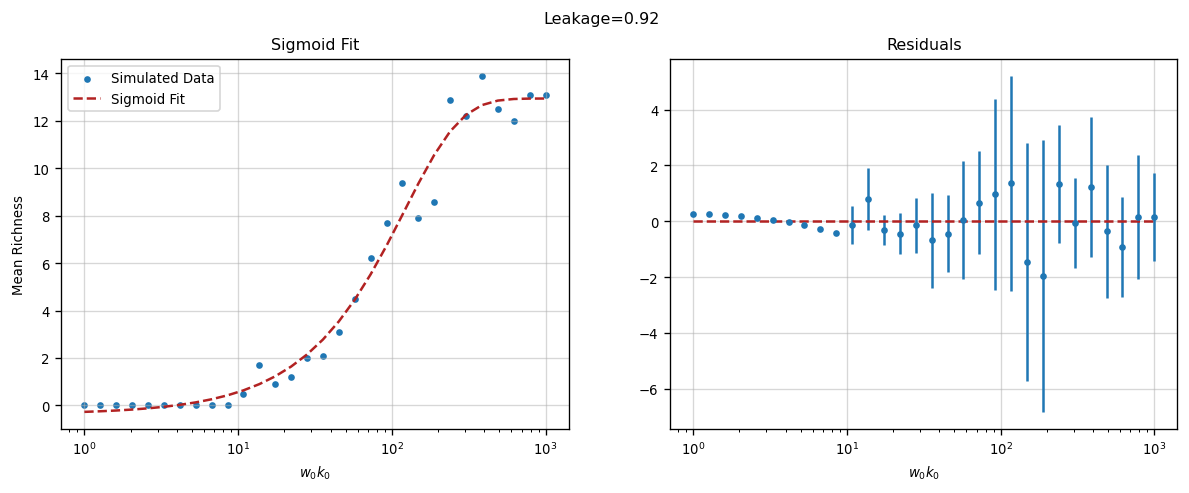

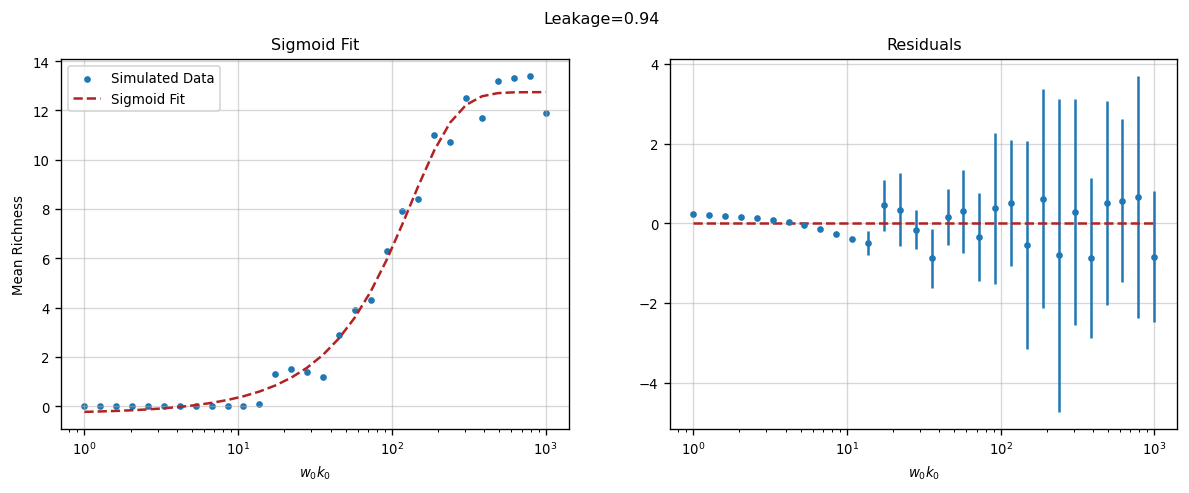

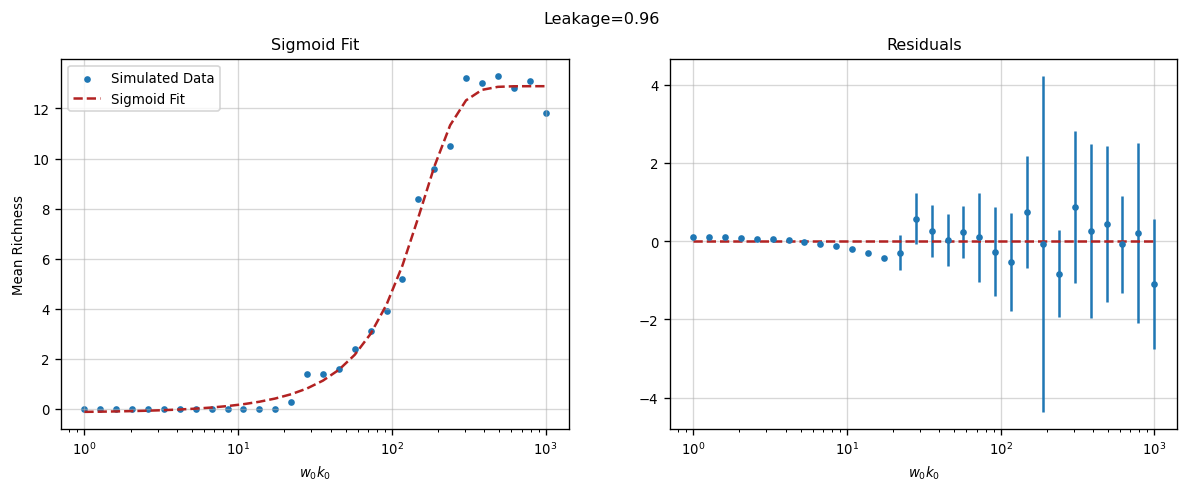

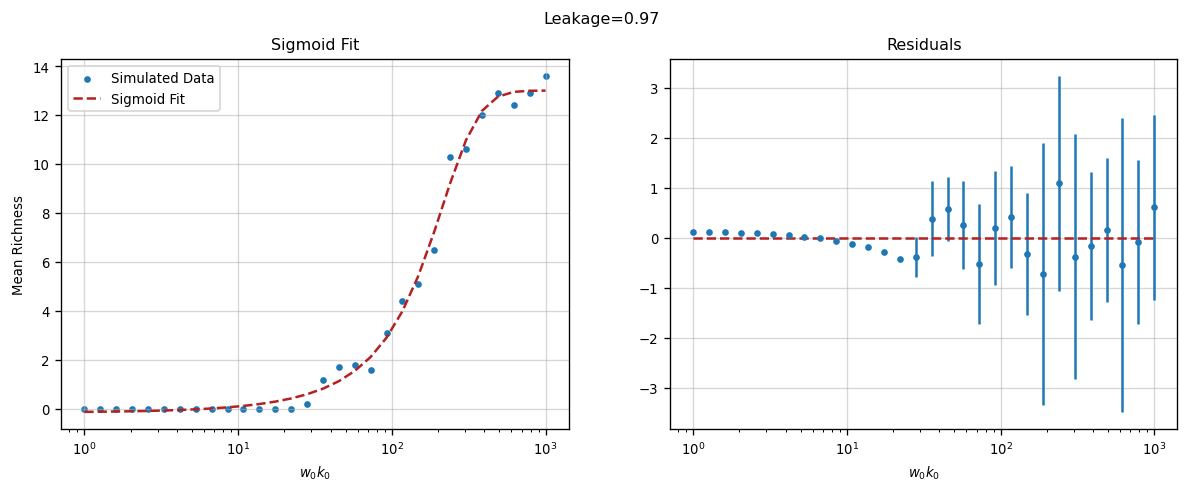

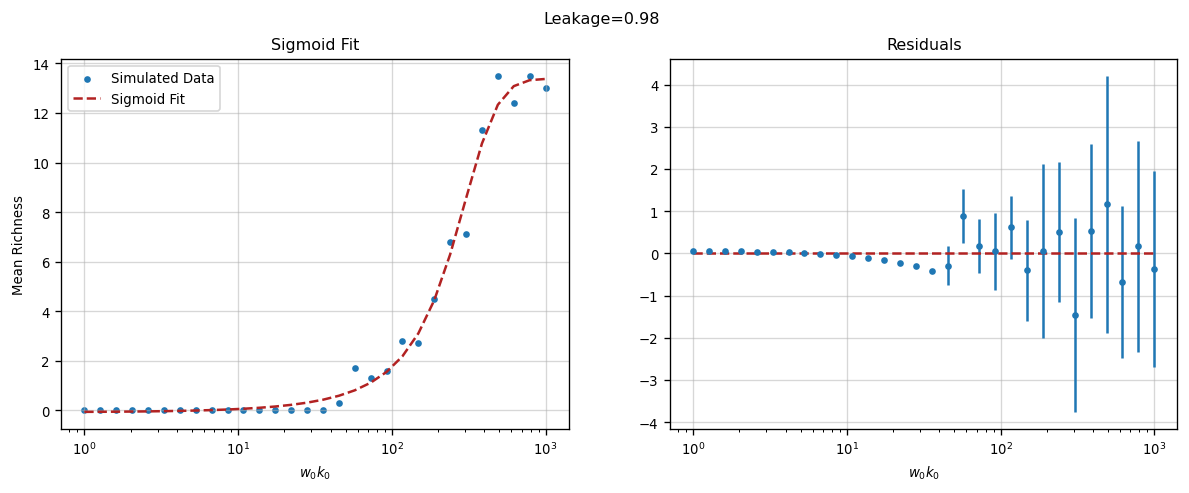

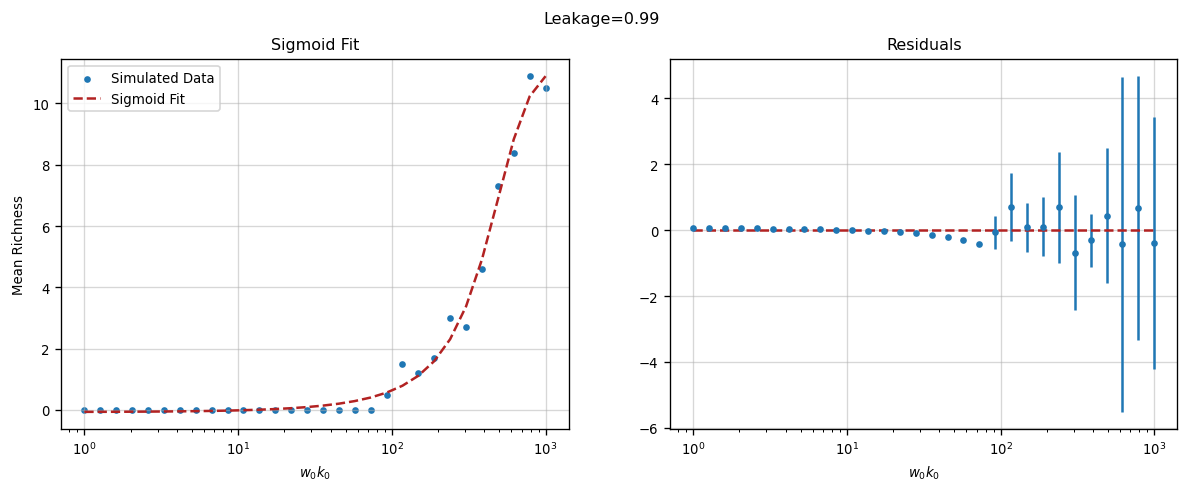

In [9]:
Fit_plots(wk_fine,mean_results_80,fit_80,residuals_80,std_results_80,"0.8")
Fit_plots(wk_fine,mean_results_82,fit_82,residuals_82,std_results_82,"0.82")
Fit_plots(wk_fine,mean_results_84,fit_84,residuals_84,std_results_84,"0.84")
Fit_plots(wk_fine,mean_results_86,fit_86,residuals_86,std_results_86,"0.86")
Fit_plots(wk_fine,mean_results_88,fit_88,residuals_88,std_results_88,"0.88")
Fit_plots(wk_fine,mean_results_90,fit_90,residuals_90,std_results_90,"0.9")
Fit_plots(wk_fine,mean_results_92,fit_92,residuals_92,std_results_92,"0.92")
Fit_plots(wk_fine,mean_results_94,fit_94,residuals_94,std_results_94,"0.94")
Fit_plots(wk_fine,mean_results_96,fit_96,residuals_96,std_results_96,"0.96")
Fit_plots(wk_fine,mean_results_97,fit_97,residuals_97,std_results_97,"0.97")
Fit_plots(wk_fine,mean_results_98,fit_98,residuals_98,std_results_98,"0.98")
Fit_plots(wk_fine,mean_results_99,fit_99,residuals_99,std_results_99,"0.99")

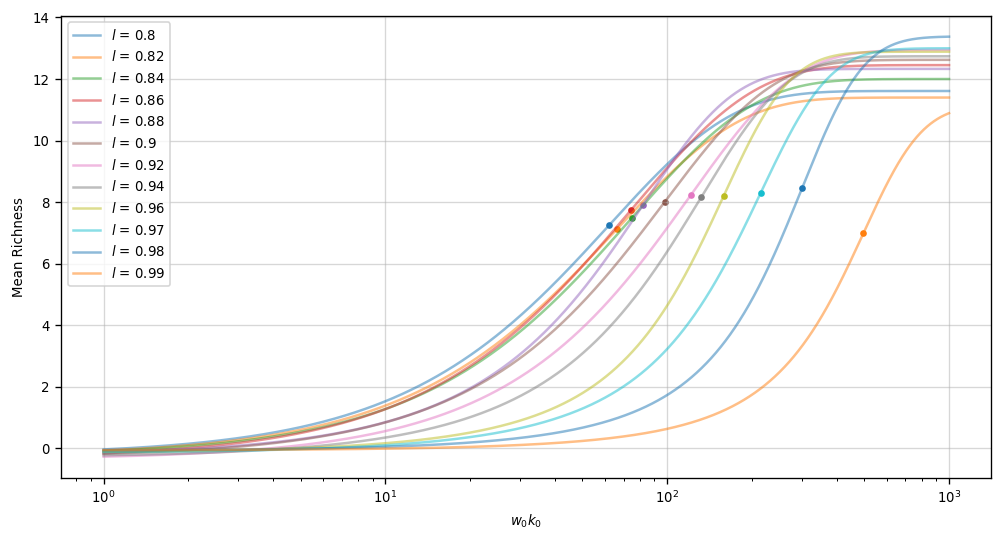

In [10]:
wk=np.logspace(0, 3, num=int(1e4), base=10)

curve_80=sigmoid(wk,*fit_params_80)
curve_82=sigmoid(wk,*fit_params_82)
curve_84=sigmoid(wk,*fit_params_84)
curve_86=sigmoid(wk,*fit_params_86)
curve_88=sigmoid(wk,*fit_params_88)

curve_90=sigmoid(wk,*fit_params_90)
curve_92=sigmoid(wk,*fit_params_92)
curve_94=sigmoid(wk,*fit_params_94)
curve_96=sigmoid(wk,*fit_params_96)
curve_97=sigmoid(wk,*fit_params_97)
curve_98=sigmoid(wk,*fit_params_98)
curve_99=sigmoid(wk,*fit_params_99)

cp_80=CriticalPoint(curve_80,wk,fit_params_80)
cp_82=CriticalPoint(curve_82,wk,fit_params_82)
cp_84=CriticalPoint(curve_84,wk,fit_params_84)
cp_86=CriticalPoint(curve_86,wk,fit_params_86)
cp_88=CriticalPoint(curve_88,wk,fit_params_88)

cp_90=CriticalPoint(curve_90,wk,fit_params_90)
cp_92=CriticalPoint(curve_92,wk,fit_params_92)
cp_94=CriticalPoint(curve_94,wk,fit_params_94)
cp_96=CriticalPoint(curve_96,wk,fit_params_96)
cp_97=CriticalPoint(curve_97,wk,fit_params_97)
cp_98=CriticalPoint(curve_98,wk,fit_params_98)
cp_99=CriticalPoint(curve_99,wk,fit_params_99)

curves=[curve_80,curve_82,curve_84,curve_86,curve_88,curve_90,curve_92,curve_94,curve_96,curve_97,curve_98,curve_99]
names = [0.8,0.82,0.84,0.86,0.88,0.9,0.92,0.94,0.96,0.97,0.98,0.99]
cps=[cp_80,cp_82,cp_84,cp_86,cp_88,cp_90,cp_92,cp_94,cp_96,cp_97,cp_98,cp_99]

plt.figure(figsize=(10,5))
for cp in cps:
    plt.scatter(cp[0],cp[1],marker=".")
for i,j in zip(curves,names):
    plt.plot(wk,i,alpha=0.5,label="$l$ = "+str(j))
plt.xscale("log")
plt.xlabel("$w_0k_0$")
plt.ylabel("Mean Richness")
plt.grid(alpha=0.5)
plt.legend();

In [11]:
cps=np.array(cps)
cps

array([[ 62.29876652,   7.25787797],
       [ 66.15795285,   7.1165265 ],
       [ 75.0218067 ,   7.49411988],
       [ 74.45385493,   7.74978834],
       [ 82.18479556,   7.92014877],
       [ 98.08422387,   8.01495909],
       [121.00638333,   8.21921312],
       [132.19411485,   8.17190154],
       [158.42363796,   8.19372921],
       [214.40411841,   8.29294176],
       [300.77921725,   8.45230537],
       [497.0151613 ,   6.9960488 ]])

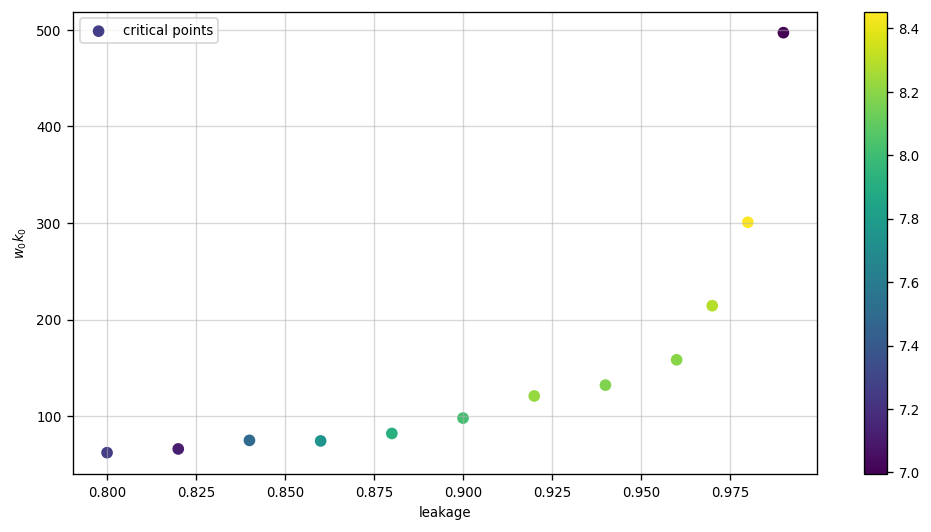

In [12]:
leakage=np.array(names)
cp_wk = cps[:,0]

plt.figure(figsize=(10,5))
plt.scatter(leakage,cp_wk,label="critical points",marker="o",c=cps[:,1])
plt.colorbar()
plt.xlabel("leakage")
plt.ylabel("$w_0k_0$")
plt.grid(alpha=0.5)
plt.legend();

In [13]:
def exponential(x, A, B, a):
    y = A * np.exp(a * x) + B
    return y

cp_wk_filtred=cp_wk[:-1]
cp_rich_filtred=cps[:,1][:-1]
leakage_filtred = leakage[:-1]

popt, pcov = curve_fit(exponential, leakage, cp_wk, maxfev=int(1e5),method="trf")

print(popt,"\n\n",pcov)

[1.07072285e-20 7.87100069e+01 5.25172966e+01] 

 [[1.44644873e-43 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]]


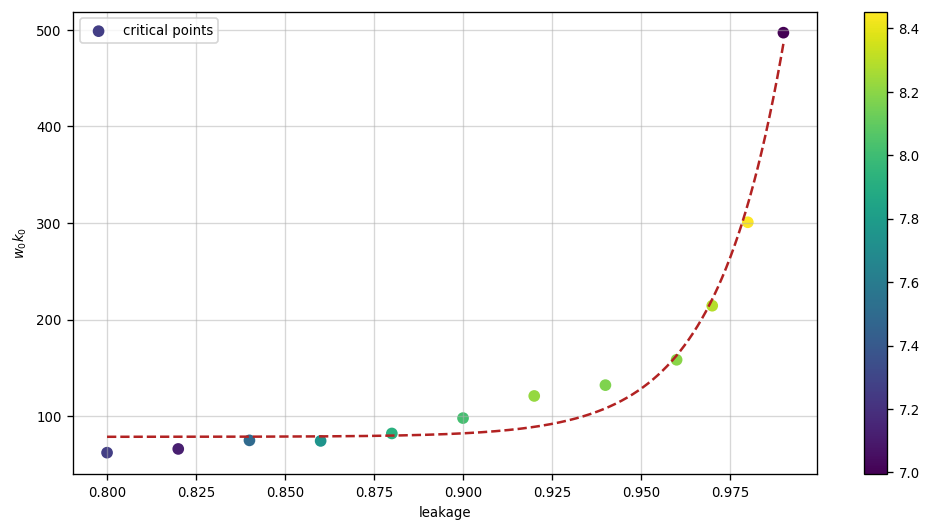

In [14]:
leakage_fine=np.linspace(0.8,0.99,int(1e4))

plt.figure(figsize=(10,5))
plt.plot(leakage_fine,exponential(leakage_fine,*popt),color="firebrick",ls="--")
plt.scatter(leakage,cp_wk,label="critical points",marker="o",c=cps[:,1])
plt.colorbar()
plt.xlabel("leakage")
plt.ylabel("$w_0k_0$")
plt.grid(alpha=0.5)
plt.legend();